# Predict Total Sales using Facebook Prophet - Exercise

![Namespace Labs](../../../../labs.png)

### Installation

pip install fbprophet

## Predict total sales

In [1]:
from prophet import Prophet
import pandas as pd

In [2]:
df = pd.read_csv('sales.csv')

In [3]:
df.head()

,ds,y
0,1/10/2011,36529.3764
1,1/11/2011,102403.8663
2,1/12/2011,36177.7578
3,1/13/2011,31005.6454
4,1/14/2011,71539.6626


In [4]:
# Print the head of the dataset


In [5]:
df.tail()

,ds,y
300,9/5/2011,55634.5004
301,9/6/2011,42359.4562
302,9/7/2011,51529.7315
303,9/8/2011,40329.0800
304,9/9/2011,44269.7119


In [6]:
# Print the tail of the dataframe


In [7]:
model = Prophet()
model.fit(df)

09:10:24 - cmdstanpy - INFO - Chain [1] start processing
09:10:24 - cmdstanpy - INFO - Chain [1] done processing


In [8]:
# Create an instance of prophet
# Fit the data to the model


In [9]:
future = model.make_future_dataframe(periods=365)
future.tail()

,ds
665,2012-12-04
666,2012-12-05
667,2012-12-06
668,2012-12-07
669,2012-12-08


In [10]:
# Create a dataframe for future dates
# Print the head of the dataframe


In [11]:
# Make predictions on the model
predictions = model.predict(future)

In [12]:
predictions.head(1)

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,weekly,weekly_lower,weekly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,2010-12-01,47328.720076,21617.672367,68652.142354,47328.720076,47328.720076,-1886.557492,-1886.557492,-1886.557492,-1886.557492,-1886.557492,-1886.557492,0.0,0.0,0.0,45442.162585


In [13]:
# Display one row from the predictions


In [14]:
predictions[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail()

,ds,yhat,yhat_lower,yhat_upper
665,2012-12-04,203530.541695,166933.904838,242105.932165
666,2012-12-05,196116.656529,158005.718259,234437.059105
667,2012-12-06,207099.534442,167333.100747,245726.947752
668,2012-12-07,193114.394915,155749.147607,230499.782659
669,2012-12-08,219504.672209,184235.992317,258435.834890


In [15]:
# Display the tail of the forecasts


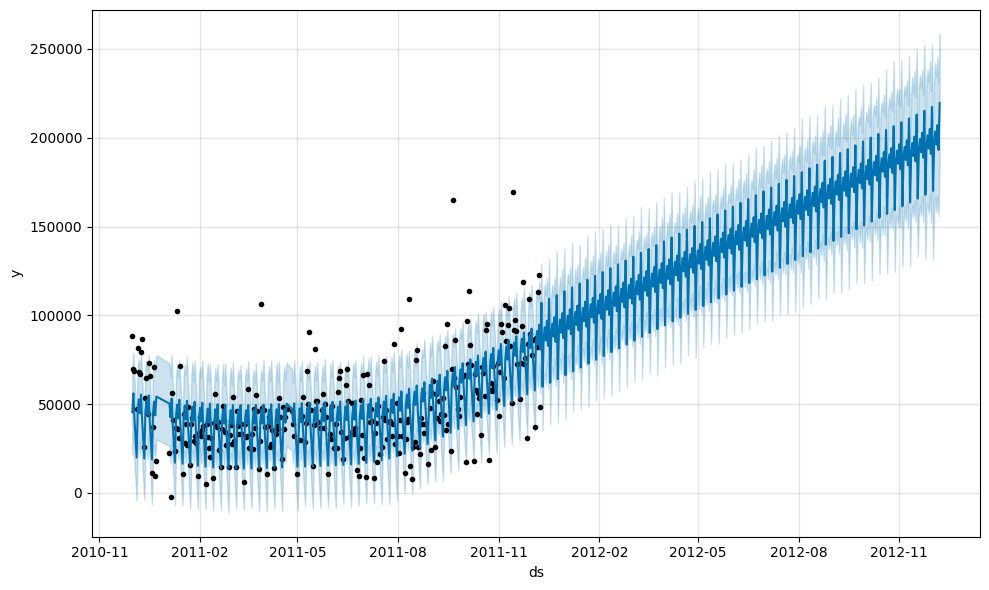

In [16]:
fig1 = model.plot(predictions)

In [17]:
# Plot the forecast

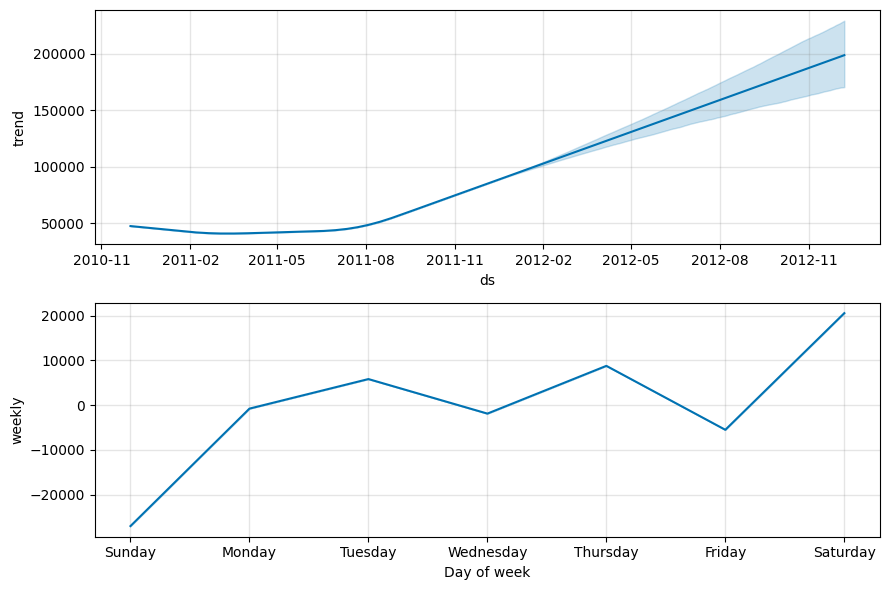

In [18]:
fig2 = model.plot_components(predictions)

In [19]:
# Plot the model components


In [20]:
df

,ds,y
0,1/10/2011,36529.3764
1,1/11/2011,102403.8663
2,1/12/2011,36177.7578
3,1/13/2011,31005.6454
4,1/14/2011,71539.6626
...,...,...
300,9/5/2011,55634.5004
301,9/6/2011,42359.4562
302,9/7/2011,51529.7315
303,9/8/2011,40329.0800


In [21]:
from prophet.diagnostics import cross_validation
df_cv = cross_validation(model, horizon = '50 days')
df_cv

  0%|          | 0/7 [00:00<?, ?it/s]

09:10:33 - cmdstanpy - INFO - Chain [1] start processing
09:10:34 - cmdstanpy - INFO - Chain [1] done processing
09:10:34 - cmdstanpy - INFO - Chain [1] start processing
09:10:34 - cmdstanpy - INFO - Chain [1] done processing
09:10:35 - cmdstanpy - INFO - Chain [1] start processing
09:10:35 - cmdstanpy - INFO - Chain [1] done processing
09:10:36 - cmdstanpy - INFO - Chain [1] start processing
09:10:36 - cmdstanpy - INFO - Chain [1] done processing
09:10:36 - cmdstanpy - INFO - Chain [1] start processing
09:10:37 - cmdstanpy - INFO - Chain [1] done processing
09:10:37 - cmdstanpy - INFO - Chain [1] start processing
09:10:37 - cmdstanpy - INFO - Chain [1] done processing
09:10:38 - cmdstanpy - INFO - Chain [1] start processing
09:10:38 - cmdstanpy - INFO - Chain [1] done processing


,ds,yhat,yhat_lower,yhat_upper,y,cutoff
0,2011-05-24,53143.043626,32952.114891,72162.643752,55913.6541,2011-05-23
1,2011-05-25,39282.173744,19363.386196,57856.600456,36469.9428,2011-05-23
2,2011-05-26,47973.600564,27620.639367,67190.646962,50144.9709,2011-05-23
3,2011-05-27,45628.605544,25718.107547,64269.499875,42630.6069,2011-05-23
4,2011-05-29,19734.366975,1311.951053,37618.066413,10884.5330,2011-05-23
...,...,...,...,...,...,...
292,2011-12-05,65255.438122,42759.555354,87245.426861,87204.4932,2011-10-20
293,2011-12-06,75182.867261,51478.904042,96173.407599,81884.8387,2011-10-20
294,2011-12-07,64936.057250,41123.019512,86410.812526,113365.0922,2011-10-20
295,2011-12-08,77551.825910,54928.785552,99161.205338,122940.8478,2011-10-20


In [22]:
# Perform cross validation


In [23]:
from prophet.diagnostics import performance_metrics
df_p = performance_metrics(df_cv)
df_p.head()

,horizon,mse,rmse,mae,mape,mdape,smape,coverage
0,5 days,2.929238e+08,17115.017390,12232.852837,0.310822,0.276451,0.283737,0.839080
1,6 days,2.573700e+08,16042.754207,11517.322864,0.328829,0.276451,0.283667,0.867816
2,7 days,2.924931e+08,17102.429495,12517.175032,0.415523,0.276451,0.317609,0.827586
3,8 days,3.576965e+08,18912.865449,13340.107502,0.440206,0.281053,0.331767,0.758621
4,9 days,3.646899e+08,19096.856053,14079.810293,0.493851,0.292694,0.365828,0.793103


In [24]:
# Display the performance metrics


/home/janusz/Desktop/udemy data science/Machine Learning/venv/lib/python3.12/site-packages/prophet/plot.py:547: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.
  x_plt = df_none['horizon'].astype('timedelta64[ns]').view(np.int64) / float(dt_conversions[i])
/home/janusz/Desktop/udemy data science/Machine Learning/venv/lib/python3.12/site-packages/prophet/plot.py:548: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.
  x_plt_h = df_h['horizon'].astype('timedelta64[ns]').view(np.int64) / float(dt_conversions[i])


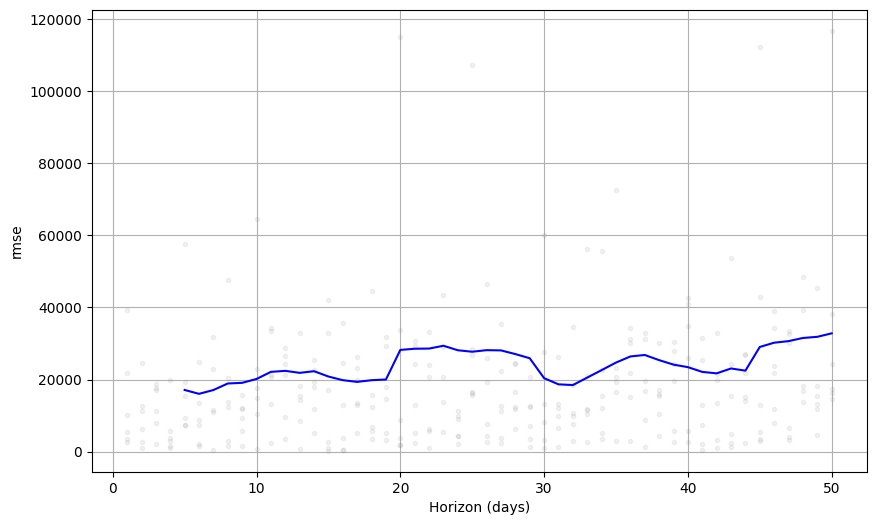

In [25]:
from prophet.plot import plot_cross_validation_metric
fig = plot_cross_validation_metric(df_cv, metric='rmse')

In [26]:
# Plot the performance metrics


Happy Coding!